<a href="https://colab.research.google.com/github/Jame00000001/B11A1-Website/blob/main/Credit_Card_Fraud_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.) Importing Libraries:

The first step of all the projects will be always importing the required libraries

In [12]:
# import libraries for ProjectGurukul Credit Card Fraud Detection Project using Machine Learning:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , accuracy_score, classification_report

2.) Load the dataset:

Load the dataset we have downloaded above which is creditcard.csv file. **bold text**

In [13]:
#Loading the dataset to a Pandas Dataframe

credit_card_data = pd.read_csv('/creditcard.csv')

In [14]:
credit_card_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [15]:
credit_card_data.isnull().sum().sum()

np.int64(0)

**3.) Analysing and Visualizing the dataset:

In this step we will analyze the dataset and perform certain operations to clean the data and make it ready, to train our model. And also we will visualize the dataset.:**

> Add blockquote



In [16]:
# let's see first 5 rows of the dataset:
credit_card_data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
# let's see last 5 rows of our dataset:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [18]:
# dataset information:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [19]:
# checking number of missing values:
credit_card_data.isnull().sum()

# Find distribution of Normal transaction or Fraud transaction:
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


In [40]:
print(credit_card_data.shape)
print(credit_card_data['Class'].value_counts(normalize=True))


(284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


Now we will separate Normal and Fraud transactions, and analyze and visualize that fraud and normal data :


(284315, 31)
(492, 31)


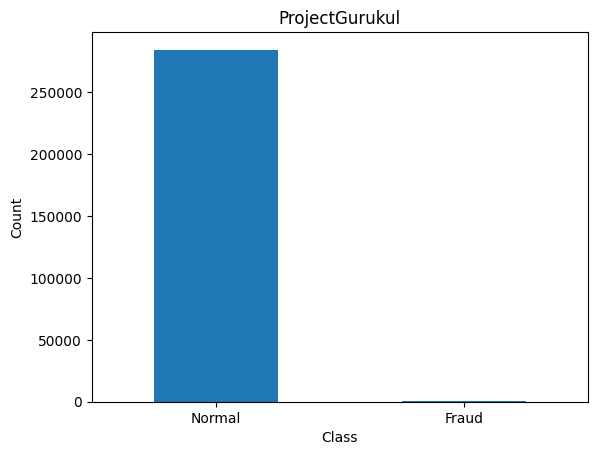

In [43]:
# Separating the data:
normal = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]
# check shape
print(normal.shape)
print(fraud.shape)

#visualize the data:
labels = ["Normal", "Fraud"]
count_classes = credit_card_data.value_counts(credit_card_data['Class'], sort= True)
count_classes.plot(kind = "bar", rot = 0)
plt.title("ProjectGurukul")
plt.ylabel("Count")
plt.xticks(range(2), labels)
plt.show()

We will perform some statistical analysis of the data:

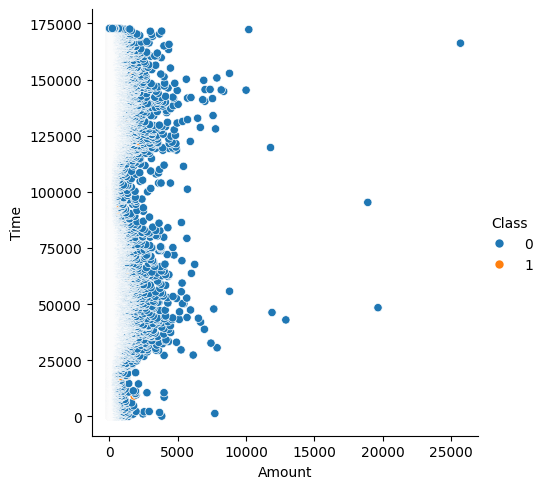

In [44]:
# statistical measures of the data:
normal.Amount.describe()
fraud.Amount.describe()

# visualize the data using seaborn:
sns.relplot(x = 'Amount' , y = 'Time' , hue = 'Class', data = credit_card_data)

We are just performing Exploratory data analysis, just follow along to understand the dataset better. And make it better so that our model can detect fraud and normal transactions accurately and efficiently.


In [47]:
# Compare values of both transactions:
credit_card_data.groupby('Class').mean()

# Now we will build a sample dataset containing similar distribution of normal transaction and fraud transaction:
normal_sample = normal.sample(n=492)
# Concat two data ( normal_sample and fraud) to create new dataframe which consist equal number of fraud transactions and normal transactions, In this way we balance our dataset (As our dataset is highly unbalanced initially) :
credit_card_new_data = pd.concat([normal_sample, fraud], axis=0)
# Let’s see our new dataset:
# credit_card_new_data

# Analyse our new dataset:
credit_card_new_data['Class'].value_counts()

,count
Class,
0,492
1,492


4) Splitting the data:

After analyzing and visualizing our data, now we will split our dataset in X and Y or say in features and labels:

In [48]:
# Splitting data into features and targets
X = credit_card_new_data.drop('Class', axis=1)
Y = credit_card_new_data['Class']

# splitting the data into training and testing data:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify = Y, random_state= 2)
print(X.shape, X_train.shape, X_test.shape)

(984, 30) (787, 30) (197, 30)


5.) Creating Logistic Regression Model:

Now we will create the machine learning model.

In [49]:
# Creating Model:
model = LogisticRegression()
# training the Logistic Regression model with training data:
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

6.) Model Evaluation:

After fitting the data into the model we have to perform model evaluation to check the accuracy of the model.

In [94]:
# Model Evaluation
X_train_pred = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_pred, Y_train)
print('Accuracy of Training data:', training_data_accuracy)

Accuracy of Training data: 0.49682337992376113


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


As you can see the model we have created gives 94% accuracy on training data. The accuracy is very good as we are training our model on very less data. So on considering that our model accuracy is good.

In [91]:
# classification report of the model on training data:
print(classification_report(X_train_pred, Y_train))

              precision    recall  f1-score   support

           0       0.63      0.50      0.55       495
           1       0.37      0.50      0.42       292

    accuracy                           0.50       787
   macro avg       0.50      0.50      0.49       787
weighted avg       0.53      0.50      0.51       787



Now evaluating our model on test data:

In [81]:
# accuracy on test data:
X_test_pred = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_pred, Y_test)
print('Accuracy of Testing data:', test_data_accuracy)

# confusion matrix and classification report of test data:
print(confusion_matrix(X_test_pred, Y_test))
print(classification_report(X_test_pred, Y_test))

Accuracy of Testing data: 0.4416243654822335
[[59 70]
 [40 28]]
              precision    recall  f1-score   support

           0       0.60      0.46      0.52       129
           1       0.29      0.41      0.34        68

    accuracy                           0.44       197
   macro avg       0.44      0.43      0.43       197
weighted avg       0.49      0.44      0.46       197



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [64]:
# 1️⃣ আলাদা করো – Fraud & Normal Data
normal = credit_card_data[credit_card_data.Class == 0]
fraud  = credit_card_data[credit_card_data.Class == 1]

print(normal.shape)
print(fraud.shape)


(284315, 31)
(492, 31)


In [65]:
# Normal dataset থেকে Fraud এর সমান sample নিবো:
normal_sample = normal.sample(n=len(fraud))

new_dataset = pd.concat([normal_sample, fraud], axis=0)

print(new_dataset['Class'].value_counts())


Class
0    492
1    492
Name: count, dtype: int64


In [66]:
# 3️⃣ এখন Model Train এর জন্য প্রস্তুতি
X = new_dataset.drop(columns='Class', axis=1)
y = new_dataset['Class']


In [67]:
normal = credit_card_data[credit_card_data.Class == 0]
fraud  = credit_card_data[credit_card_data.Class == 1]

normal_sample = normal.sample(n=len(fraud))

new_dataset = pd.concat([normal_sample, fraud], axis=0)

print(new_dataset['Class'].value_counts())


Class
0    492
1    492
Name: count, dtype: int64


In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

2️⃣ Prepare Features and Target

In [69]:
# X = features, y = target
X = new_dataset.drop(columns='Class', axis=1)
y = new_dataset['Class']

# Scale features (important for ML algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


> ✅ Scaling দিলে Logistic Regression এবং Random Forest ভালো কাজ করে



# 3️⃣ Train-Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)






> 80% train, 20% test
>random_state=42 → result ?>reproducible




# 4️⃣ Logistic Regression Model

In [96]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)



#5️⃣ Random Forest Model



In [97]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


# 6️⃣ Model Evaluation
# Accuracy, Precision, Recall


=== Logistic Regression ===
Accuracy : 0.9390862944162437
Precision: 0.9886363636363636
Recall   : 0.8877551020408163


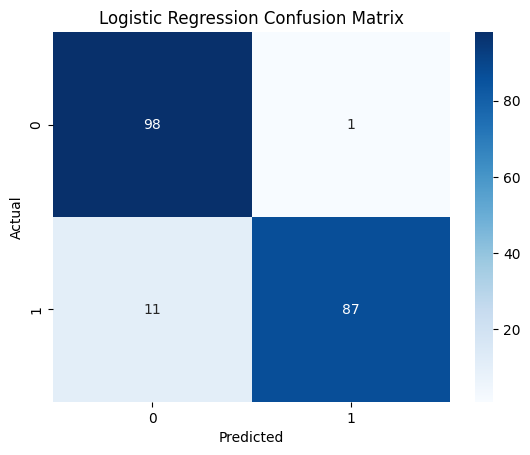


=== Random Forest ===
Accuracy : 0.9289340101522843
Precision: 0.9772727272727273
Recall   : 0.8775510204081632


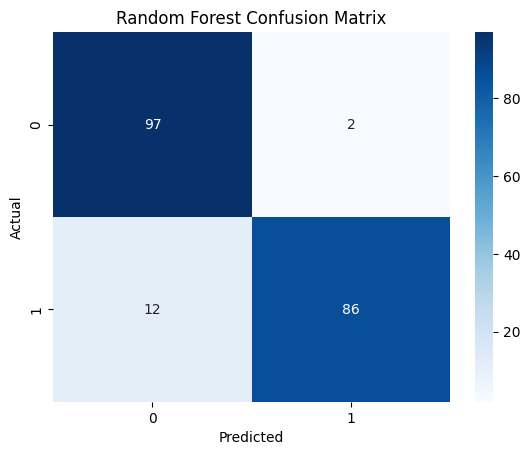

In [77]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n=== {model_name} ===")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic Regression
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
evaluate_model(y_test, y_pred_rf, "Random Forest")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:39:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Best Model (based on Recall): XGBoost

--- Logistic Regression ---
Accuracy : 0.9391
Precision: 0.9886
Recall   : 0.8878


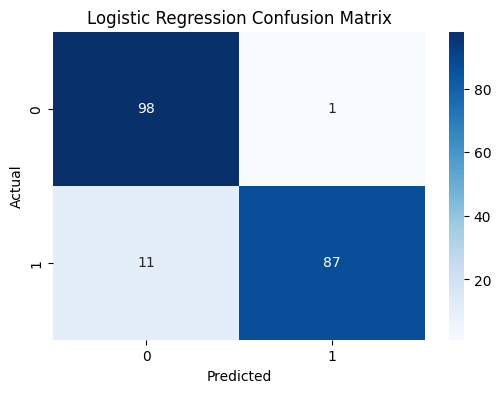

--- Random Forest ---
Accuracy : 0.9289
Precision: 0.9773
Recall   : 0.8776


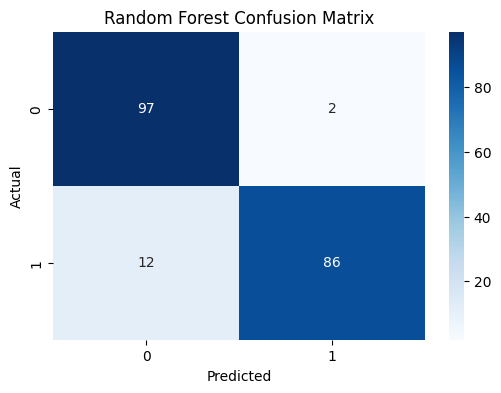

--- XGBoost ---
Accuracy : 0.9289
Precision: 0.9565
Recall   : 0.8980


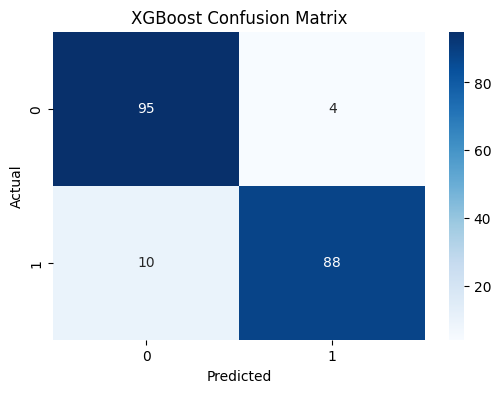

In [98]:
# ================= IMPORT =================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ================= PREPARE DATA =================
X = new_dataset.drop(columns='Class', axis=1)
y = new_dataset['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ================= MODELS =================
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

# ================= TRAIN & EVALUATE =================
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

# ================= DISPLAY RESULTS =================
best_model_name = max(results, key=lambda x: results[x]['Recall'])  # Fraud detection জন্য Recall গুরুত্বপূর্ণ

print(f"\n✅ Best Model (based on Recall): {best_model_name}\n")

for name, metrics in results.items():
    print(f"--- {name} ---")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")

    plt.figure(figsize=(6,4))
    sns.heatmap(metrics['Confusion Matrix'], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
